In [2]:
!unzip wine+quality.zip

Archive:  wine+quality.zip
  inflating: winequality-red.csv     
  inflating: winequality-white.csv   
  inflating: winequality.names       


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler

In [8]:
# Load red wine dataset
df = pd.read_csv("winequality-red.csv", sep=";")

# Quick overview
print(df.head())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [9]:
np.max(df["quality"])

8

In [10]:
df["quality"].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


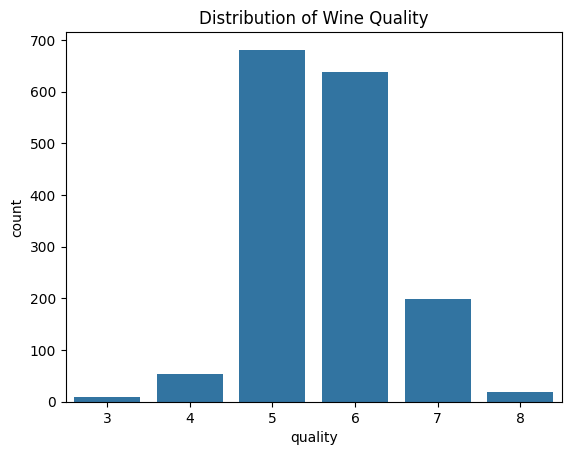

In [11]:
#dataset improportionlity
sns.countplot(x="quality", data=df)
plt.title("Distribution of Wine Quality")
plt.show()

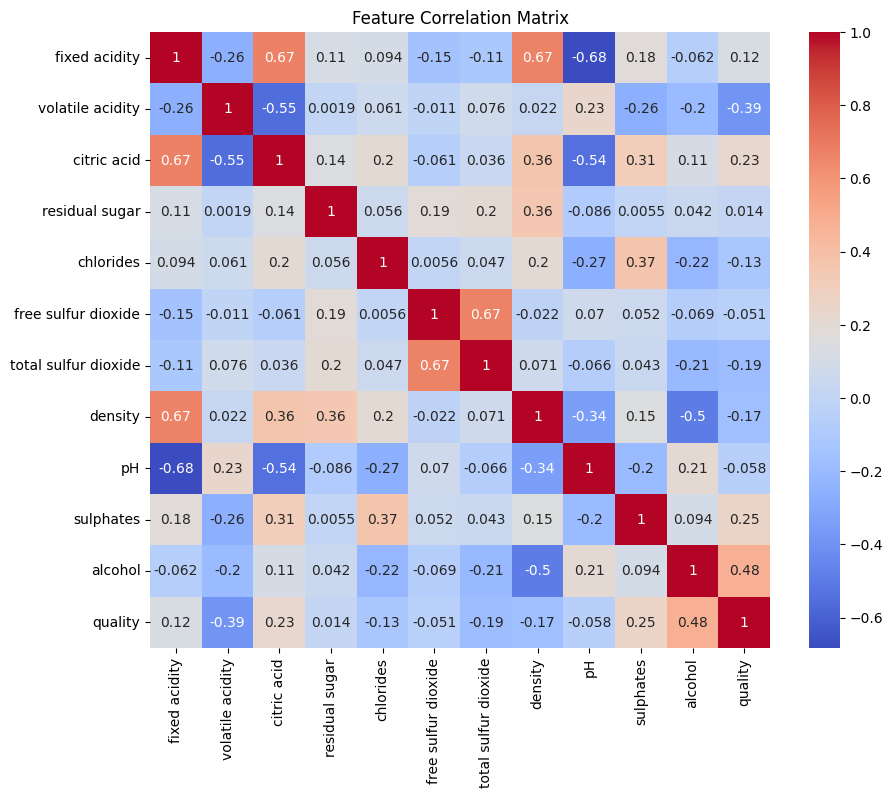

In [12]:
#correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [13]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Finalize model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [17]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

RMSE: 0.553
R² Score: 0.532


In [18]:
importances = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

                 Feature  Importance
10               alcohol    0.272652
9              sulphates    0.151100
1       volatile acidity    0.108390
6   total sulfur dioxide    0.077636
4              chlorides    0.070043
8                     pH    0.061484
3         residual sugar    0.058068
7                density    0.052488
0          fixed acidity    0.052336
2            citric acid    0.048978
5    free sulfur dioxide    0.046824


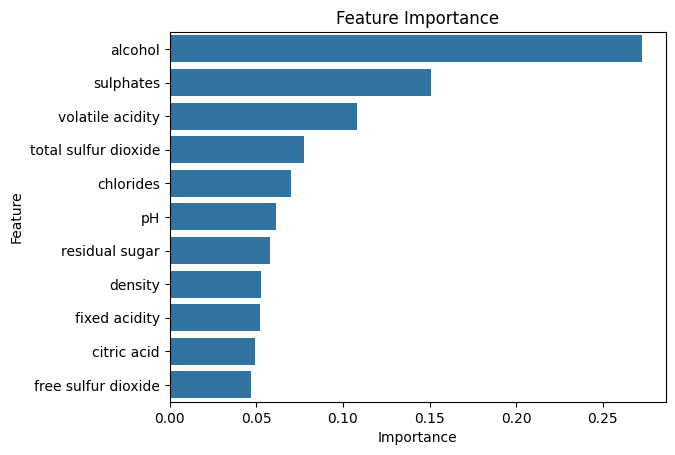

In [19]:
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

In [22]:
# Convert into categories
df["quality_label"] = df["quality"].apply(
    lambda x: "low" if x <= 5 else ("medium" if x <= 7 else "high")
)

In [23]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [36]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)
model1 = RandomForestClassifier(n_estimators=200, random_state=42)
model1.fit(X_train, y_train)

ValueError: could not convert string to float: 'medium'

In [35]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average="weighted")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- quality_label


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [ ]:
recall_score(y_test, y_pred, average=None)